 ### 1. Import Required Libraries

In [316]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

### 2. Load Datasets

In [317]:
# import pandas as pd
df1 = pd.read_csv('studentInfo.csv')
df2 = pd.read_csv('studentAssessment.csv')
df3 = pd.read_csv('studentRegistration.csv')

### 3. Prelimary Data Exploration

In [318]:
all_dfs = {
    'Student Info': df1,
    'Student Assessment': df2,
    'Student Registration': df3
}



for df in all_dfs.values():
    display(df.head())

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [319]:
for name, df in all_dfs.items():
    print(f"The shape of {name} is {df.shape}")

The shape of Student Info is (32593, 12)
The shape of Student Assessment is (173912, 5)
The shape of Student Registration is (32593, 5)


In [320]:
df1['final_result'].unique()

array(['Pass', 'Withdrawn', 'Fail', 'Distinction'], dtype=object)

### 4. Data Cleaning

#### 4.1 Merge Datasets

In [321]:
merged_df = df1.merge(df3,
                      on=['code_module', 'code_presentation', 'id_student'],
                      how='left')

In [322]:
merged_df = merged_df.merge(df2,
                            on=['id_student'],
                            how='left')

In [323]:
merged_df.head(3)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,id_assessment,date_submitted,is_banked,score
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN,1752.0,18.0,0.0,78.0
1,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN,1753.0,53.0,0.0,85.0
2,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN,1754.0,115.0,0.0,80.0


#### 4.3 Descriptive Statistics

In [324]:
merged_df.describe()

,id_student,num_of_prev_attempts,studied_credits,date_registration,date_unregistration,id_assessment,date_submitted,is_banked,score
count,2.131660e+05,213166.000000,213166.000000,213077.000000,30431.000000,207319.000000,207319.000000,207319.000000,207092.000000
mean,7.044264e+05,0.157352,78.447360,-67.760514,88.204035,26708.371727,114.501493,0.017119,75.402459
std,5.497525e+05,0.462271,38.360626,48.660345,89.097422,8428.225700,72.473110,0.129713,19.081310
min,3.733000e+03,0.000000,30.000000,-322.000000,-365.000000,1752.000000,-11.000000,0.000000,0.000000
25%,5.069300e+05,0.000000,60.000000,-96.000000,12.000000,24284.000000,50.000000,0.000000,65.000000
50%,5.856620e+05,0.000000,60.000000,-54.000000,96.000000,25357.000000,114.000000,0.000000,79.000000
75%,6.336090e+05,0.000000,90.000000,-29.000000,160.000000,34881.000000,172.000000,0.000000,89.000000
max,2.716795e+06,6.000000,655.000000,167.000000,444.000000,37443.000000,608.000000,1.000000,100.000000


#### 4.4 Address Date Registration

In [325]:
merged_df['date_registration'].isnull().sum()

89

In [326]:
# Drop students who didnt register for course at all
merged_df = merged_df.dropna(subset=['date_registration'])

In [327]:
# Confirm drop
merged_df['date_registration'].isnull().sum()

0

#### 4.3 Address Date Un-registration

In [341]:
# Drop date unregistration
merged_df = merged_df.drop(columns=['date_unregistration'])

KeyError: "['date_unregistration'] not found in axis"

#### 4.4 Drop Irrelevant Columns

In [342]:
drop_cols = [
    'id_assessment','is_banked', 'score','id_student', 
    'code_presentation', 'code_module'
]
merged_df = merged_df.drop(columns=drop_cols)

In [343]:
merged_df.head(3)

,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_submitted
0,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,18.0
1,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,53.0
2,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,115.0


#### 4.5 Remove Withdrawn from Final Result

In [329]:
merged_df = merged_df[merged_df['final_result'] != 'Withdrawn']

In [330]:
# Confirm removal
merged_df['final_result'].unique()

array(['Pass', 'Fail', 'Distinction'], dtype=object)

### 4.6 Replaced Distinction with Pass

In [331]:
merged_df['final_result'] = merged_df['final_result'].replace('Distinction', 'Pass')

In [332]:
merged_df['final_result'].unique()

array(['Pass', 'Fail'], dtype=object)

#### 4.7 Fix Missing Values: Remove all nans (rows)

In [344]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 182538 entries, 0 to 213165
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   gender                182538 non-null  object 
 1   region                182538 non-null  object 
 2   highest_education     182538 non-null  object 
 3   imd_band              174023 non-null  object 
 4   age_band              182538 non-null  object 
 5   num_of_prev_attempts  182538 non-null  int64  
 6   studied_credits       182538 non-null  int64  
 7   disability            182538 non-null  object 
 8   final_result          182538 non-null  object 
 9   date_registration     182538 non-null  float64
 10  date_submitted        181345 non-null  float64
dtypes: float64(2), int64(2), object(7)
memory usage: 16.7+ MB


In [345]:
merged_df.isnull().sum()

gender                     0
region                     0
highest_education          0
imd_band                8515
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
date_registration          0
date_submitted          1193
dtype: int64

In [346]:
merged_df = merged_df.dropna()

In [347]:
# Confirm all nans have been dropped
merged_df.isnull().sum()

gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
date_registration       0
date_submitted          0
dtype: int64

In [348]:
merged_df

,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_submitted
0,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,18.0
1,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,53.0
2,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,115.0
3,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,164.0
4,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,212.0
...,...,...,...,...,...,...,...,...,...,...,...
213161,F,Yorkshire Region,HE Qualification,50-60%,35-55,0,30,N,Pass,-28.0,169.0
213162,F,Yorkshire Region,HE Qualification,50-60%,35-55,0,30,N,Pass,-28.0,73.0
213163,F,Yorkshire Region,HE Qualification,50-60%,35-55,0,30,N,Pass,-28.0,150.0
213164,F,Yorkshire Region,HE Qualification,50-60%,35-55,0,30,N,Pass,-28.0,172.0


### 5. Data Visualization

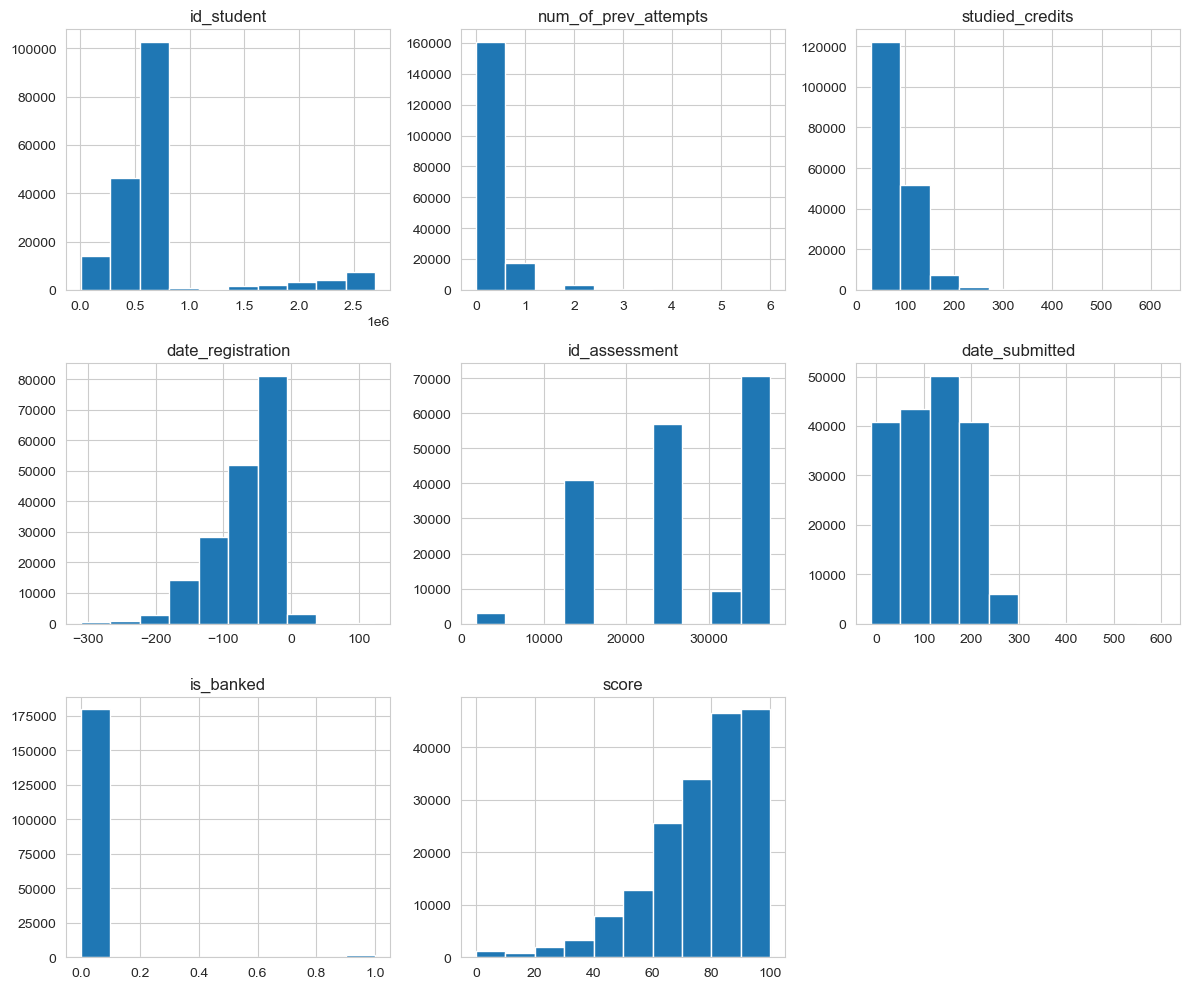

In [334]:
merged_df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

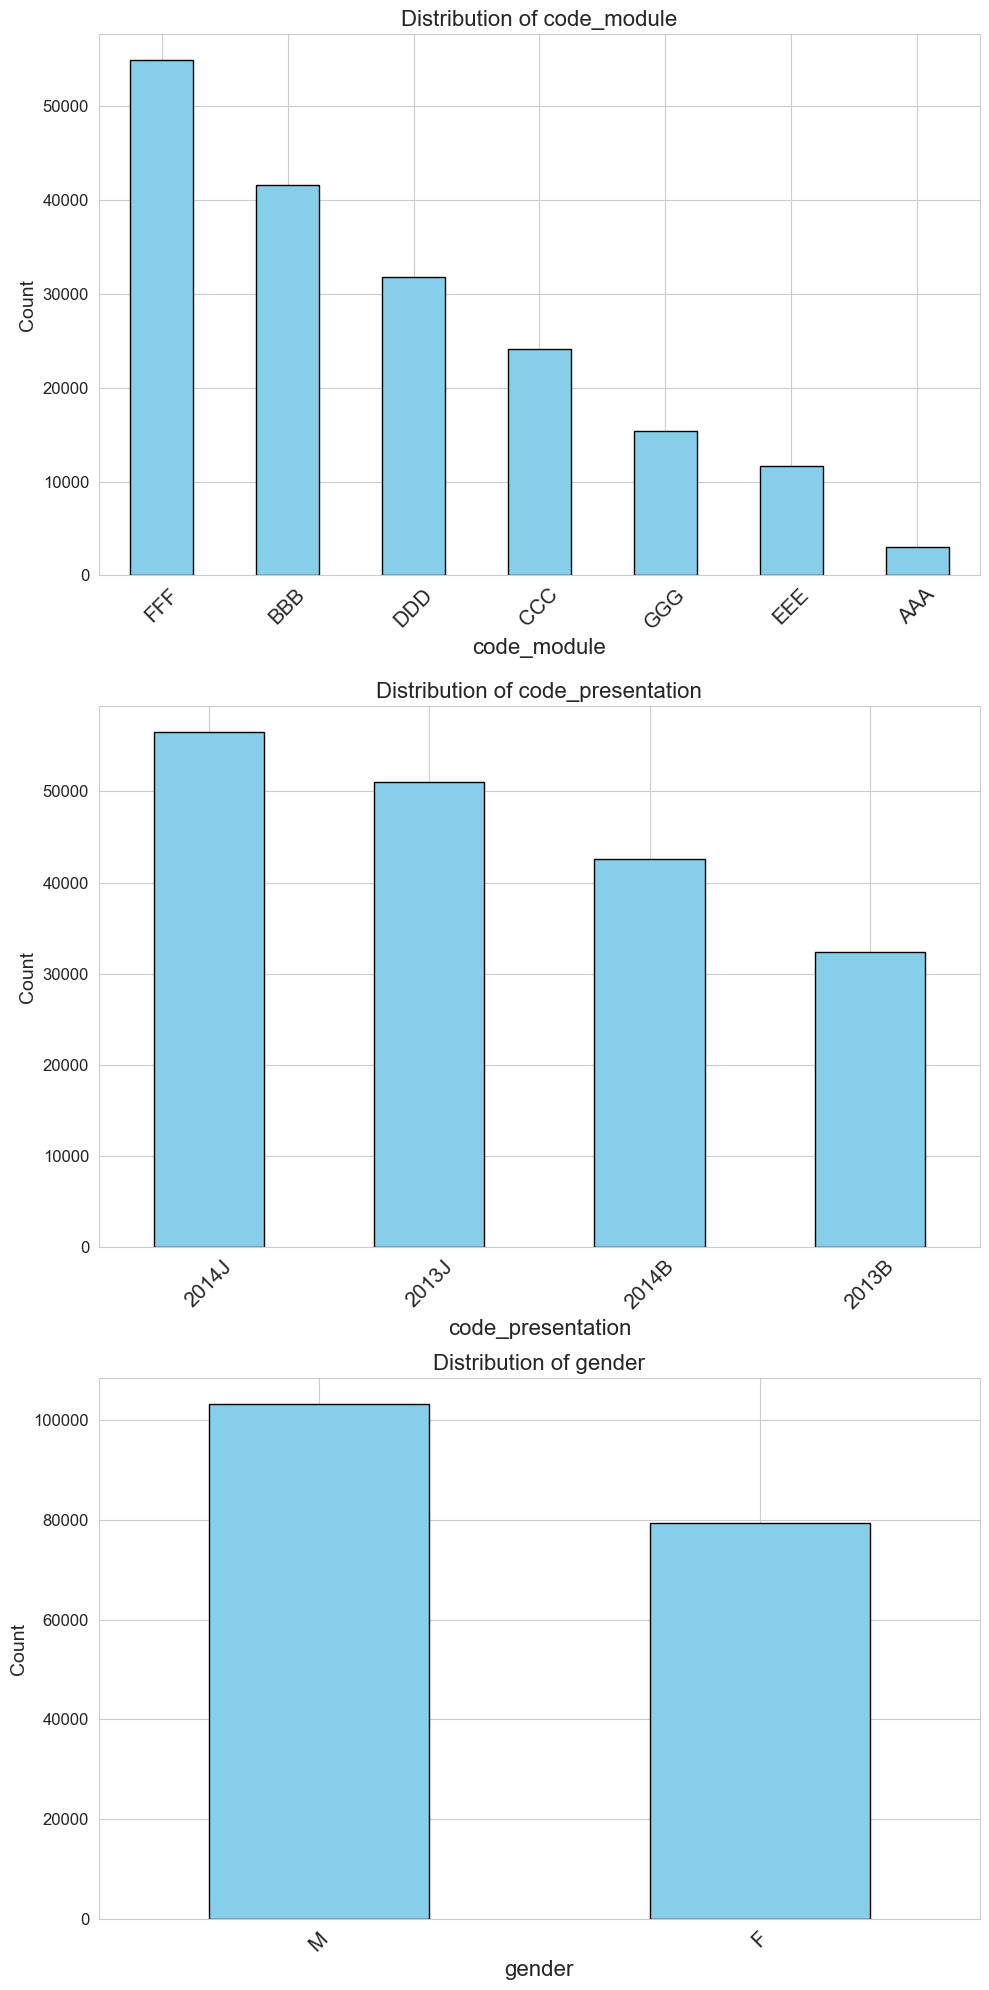

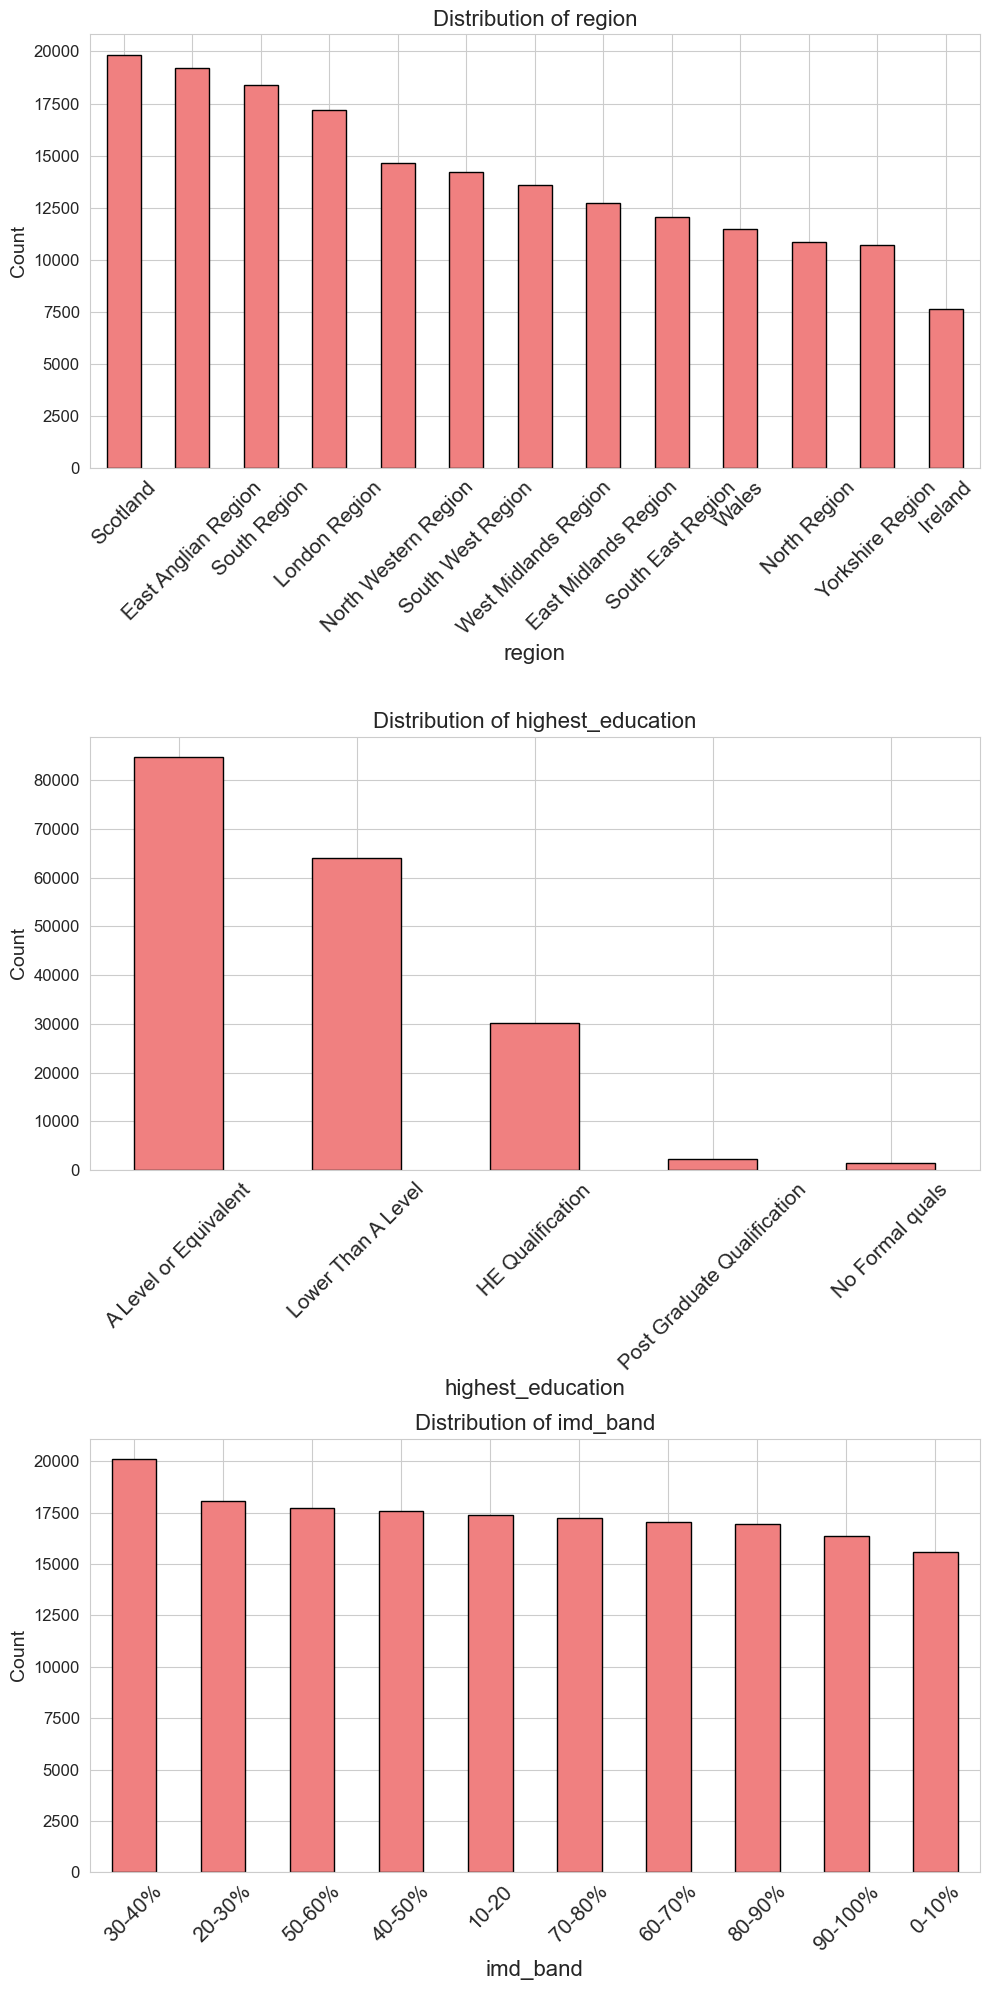

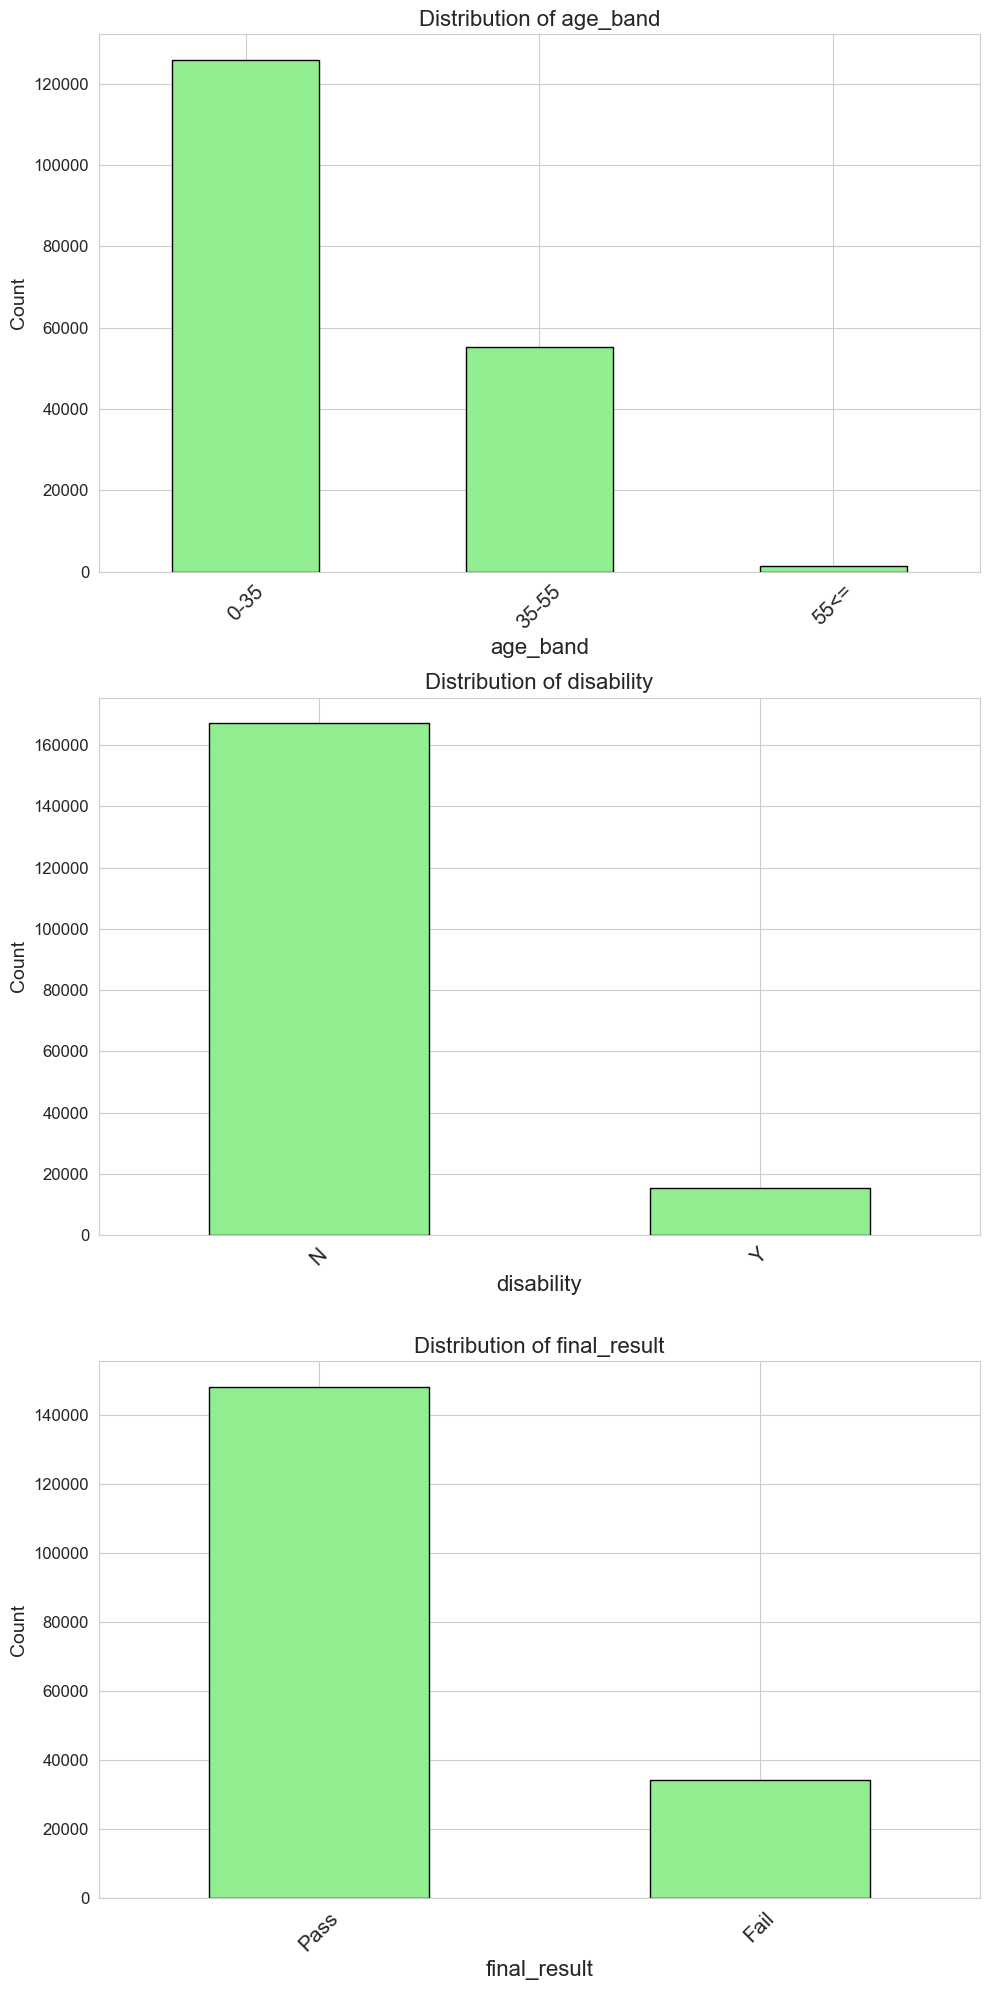

In [335]:

categorical_cols = merged_df.select_dtypes(include=['object']).columns

# Split categorical columns into three groups
group_1 = categorical_cols[:3]  # First 3 columns
group_2 = categorical_cols[3:6]  # Next 3 columns
group_3 = categorical_cols[6:]  # Last 3 columns

# Plot for Group 1
plt.figure(figsize=(10, 20))
for i, col in enumerate(group_1, start=1):
    plt.subplot(len(group_1), 1, i)
    merged_df[col].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}', fontsize=16)  # Increased title font size
    plt.ylabel('Count', fontsize=14)  # Increased y-axis font size
    plt.xlabel(col, fontsize=16)  # Increased x-axis font size
    plt.xticks(rotation=45, fontsize=15)  # Increased x-tick font size
    plt.yticks(fontsize=12)  # Increased y-tick font size

plt.tight_layout()
plt.show()

# Plot for Group 2
plt.figure(figsize=(10, 20))
for i, col in enumerate(group_2, start=1):
    plt.subplot(len(group_2), 1, i)
    merged_df[col].value_counts().plot(kind='bar', color='lightcoral', edgecolor='black')
    plt.title(f'Distribution of {col}', fontsize=16)  # Increased title font size
    plt.ylabel('Count', fontsize=14)  # Increased y-axis font size
    plt.xlabel(col, fontsize=16)  # Increased x-axis font size
    plt.xticks(rotation=45, fontsize=15)  # Increased x-tick font size
    plt.yticks(fontsize=12)  # Increased y-tick font size

plt.tight_layout()
plt.show()

# Plot for Group 3
plt.figure(figsize=(10, 20))
for i, col in enumerate(group_3, start=1):
    plt.subplot(len(group_3), 1, i)
    merged_df[col].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
    plt.title(f'Distribution of {col}', fontsize=16)  # Increased title font size
    plt.ylabel('Count', fontsize=14)  # Increased y-axis font size
    plt.xlabel(col, fontsize=16)  # Increased x-axis font size
    plt.xticks(rotation=45, fontsize=15)  # Increased x-tick font size
    plt.yticks(fontsize=12)  # Increased y-tick font size

plt.tight_layout()
plt.show()


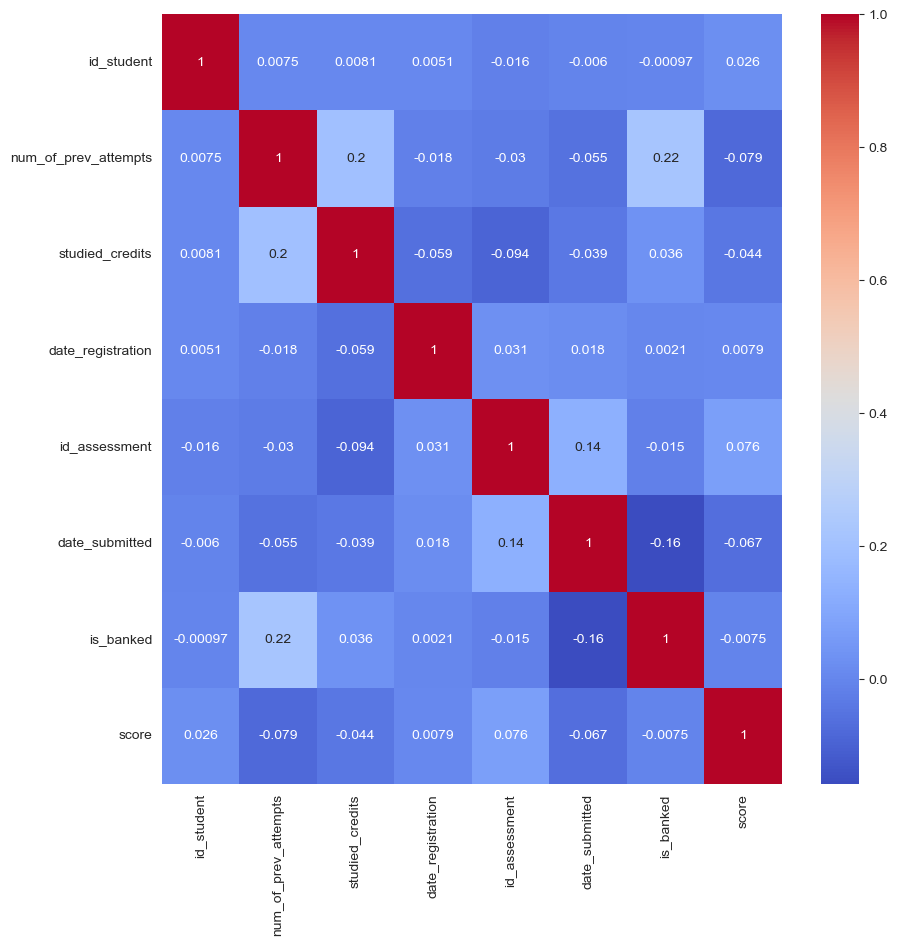

In [333]:
numerical_cols = merged_df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numerical_cols.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

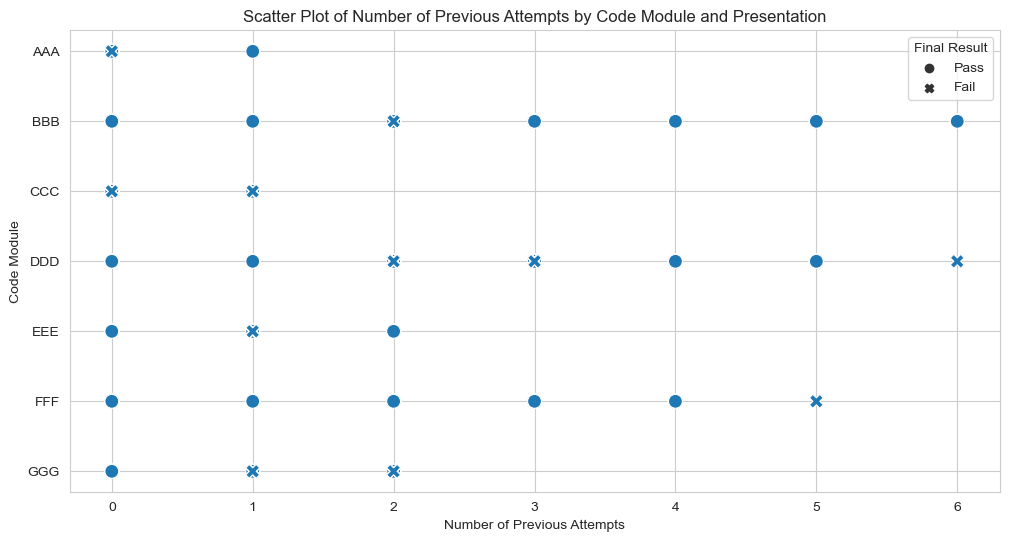

In [336]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=merged_df['num_of_prev_attempts'],
                y=merged_df['code_module'],
                style=merged_df['final_result'],
                s=100)

# Adding titles and labels
plt.title('Scatter Plot of Number of Previous Attempts by Code Module and Presentation')
plt.xlabel('Number of Previous Attempts')
plt.ylabel('Code Module')
plt.legend(title='Final Result')
plt.grid(True)

# Show the plot
plt.show()

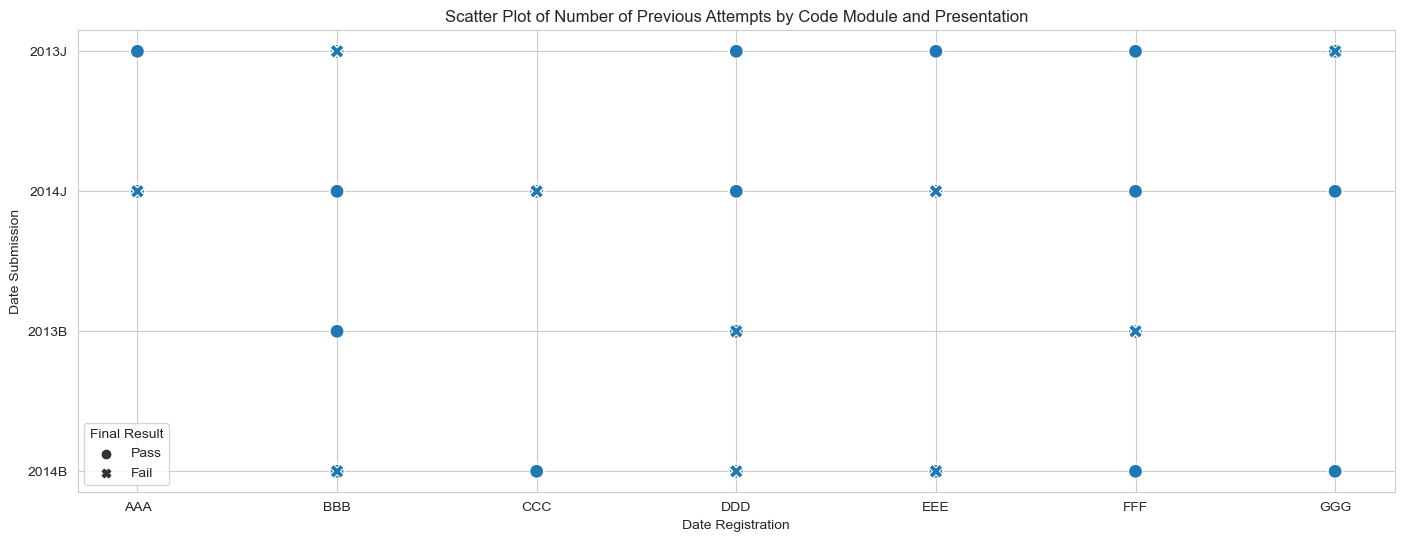

In [337]:
plt.figure(figsize=(17, 6))
sns.scatterplot(x=merged_df['code_module'],
                y=merged_df['code_presentation'],
                style=merged_df['final_result'],
                s=100)

# Adding titles and labels
plt.title('Scatter Plot of Number of Previous Attempts by Code Module and Presentation')
plt.xlabel('Date Registration')
plt.ylabel('Date Submission')
plt.legend(title='Final Result')
plt.grid(True)

# Show the plot
plt.show()

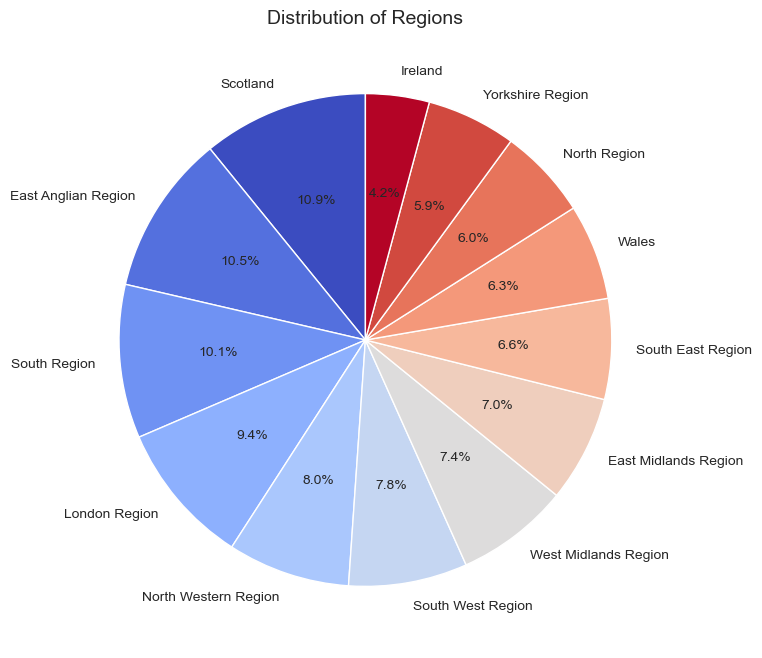

In [338]:
region_counts = merged_df['region'].value_counts()

plt.figure(figsize=(8, 8))
region_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colormap='coolwarm')
plt.title('Distribution of Regions', fontsize=14)
plt.ylabel('')

plt.show()

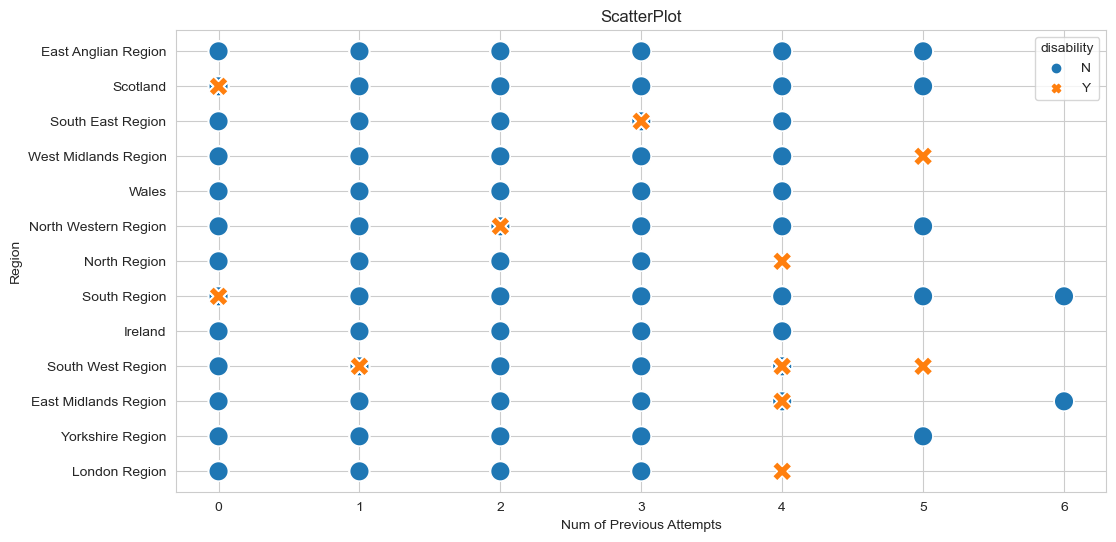

In [339]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='num_of_prev_attempts', y='region', hue='disability',style='disability', s=200,  data=merged_df)

plt.title('ScatterPlot')
plt.xlabel('Num of Previous Attempts')
plt.ylabel('Region')
plt.grid(True)

# Show the plot
plt.show()

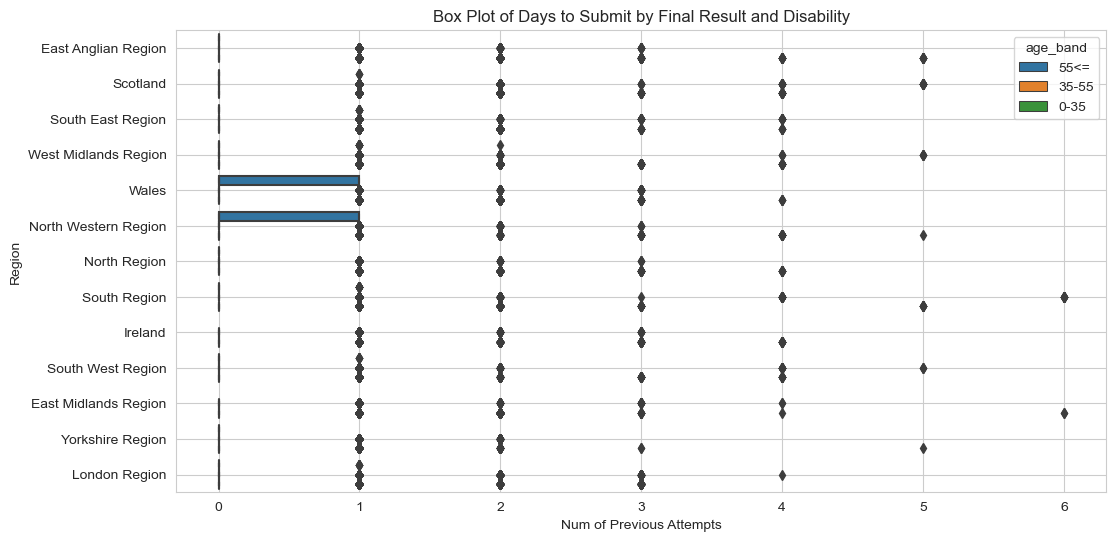

In [340]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='num_of_prev_attempts', y='region', hue='age_band', data=merged_df)

plt.title('Box Plot of Days to Submit by Final Result and Disability')
plt.xlabel('Num of Previous Attempts')
plt.ylabel('Region')
plt.grid(True)

# Show the plot
plt.show()

### 5. Data Tansformation

In [353]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn import set_config
set_config(display='diagram')

In [354]:
X = merged_df.drop(columns=['final_result'])
y = merged_df['final_result']

In [355]:
num_cols = X.select_dtypes(include=np.number).columns.to_list()
cat_cols = X.select_dtypes(exclude=np.number).columns.to_list()

print(num_cols, end='\n\n')
print(cat_cols)

['num_of_prev_attempts', 'studied_credits', 'date_registration', 'date_submitted']

['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']


In [356]:
num_pipeline = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

cat_pipeline = Pipeline(steps=[
    ('one_hot_enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [357]:
col_trans = ColumnTransformer(transformers=[
    ('num_pipeline', num_pipeline, num_cols),
    ('cat_pipeline', cat_pipeline, cat_cols),
    ],
    remainder='drop',
    n_jobs=-1
)

In [358]:
col_trans.fit(X)

ColumnTransformer(n_jobs=-1,
                  transformers=[('num_pipeline',
                                 Pipeline(steps=[('scaler', MinMaxScaler())]),
                                 ['num_of_prev_attempts', 'studied_credits',
                                  'date_registration', 'date_submitted']),
                                ('cat_pipeline',
                                 Pipeline(steps=[('one_hot_enc',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'region', 'highest_education',
                                  'imd_band', 'age_band', 'disability'])])

In [359]:
X_processed = col_trans.transform(X)

### 5.2. Partition Data into Training and Test Set

In [360]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, random_state=42, test_size=0.20)

### 5.3 Using Random Forest 

In [361]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred)
report_rf_1 = classification_report(y_test, y_pred)

print(f"Accuracy: {rf_accuracy:.4f}")
print("Classification Report:\n", report_rf_1)

Accuracy: 0.9268
Classification Report:
               precision    recall  f1-score   support

        Fail       0.91      0.67      0.77      6456
        Pass       0.93      0.99      0.96     28114

    accuracy                           0.93     34570
   macro avg       0.92      0.83      0.87     34570
weighted avg       0.93      0.93      0.92     34570


### 5.4 Using Logistics Regression

In [362]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

lg_accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {lg_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score: 0.8138

Classification Report:
              precision    recall  f1-score   support

        Fail       0.53      0.03      0.05      6456
        Pass       0.82      0.99      0.90     28114

    accuracy                           0.81     34570
   macro avg       0.67      0.51      0.47     34570
weighted avg       0.76      0.81      0.74     34570


### 5.5 Using Decision Tree

In [363]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {dt_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score: 0.8726

Classification Report:
              precision    recall  f1-score   support

        Fail       0.66      0.66      0.66      6456
        Pass       0.92      0.92      0.92     28114

    accuracy                           0.87     34570
   macro avg       0.79      0.79      0.79     34570
weighted avg       0.87      0.87      0.87     34570


### 5.6 Using Naives Bayes 

In [364]:
n_bayes = GaussianNB()
n_bayes.fit(X_train, y_train)

y_pred = n_bayes.predict(X_test)

n_bayes_accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {n_bayes_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score: 0.7043

Classification Report:
              precision    recall  f1-score   support

        Fail       0.28      0.38      0.33      6456
        Pass       0.85      0.78      0.81     28114

    accuracy                           0.70     34570
   macro avg       0.56      0.58      0.57     34570
weighted avg       0.74      0.70      0.72     34570


<Figure size 800x600 with 0 Axes>

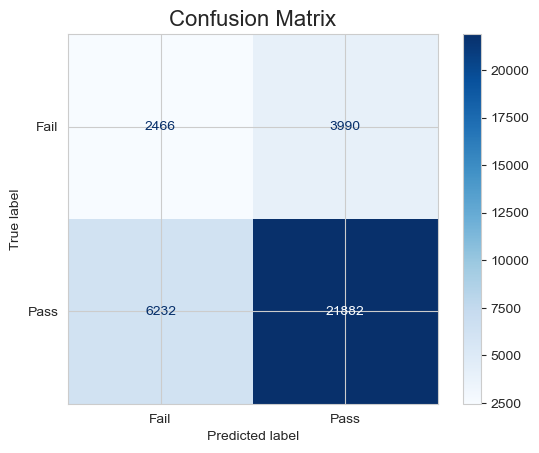

In [365]:
cm = confusion_matrix(y_test, y_pred, labels=["Fail", "Pass"])

# Create a confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail", "Pass"])

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix', fontsize=16)
plt.show()

### 6. Comparism of Models

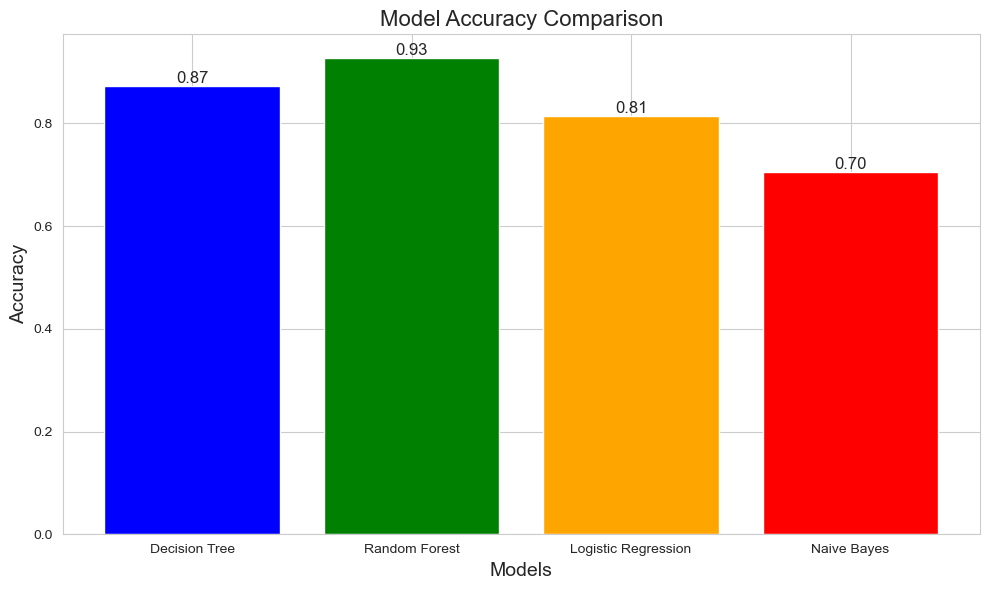

In [366]:

models = ['Decision Tree', 'Random Forest', 'Logistic Regression', 'Naive Bayes']
accuracies = [dt_accuracy, rf_accuracy, lg_accuracy, n_bayes_accuracy]  
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['blue', 'green', 'orange', 'red'])


plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)

# Add accuracy values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

### 7. Feature Importance Analysis

#### 7.1 Extract original feature names from dataset

In [367]:
feature_names = col_trans.get_feature_names_out()
print(feature_names)

['num_pipeline__num_of_prev_attempts' 'num_pipeline__studied_credits'
 'num_pipeline__date_registration' 'num_pipeline__date_submitted'
 'cat_pipeline__gender_F' 'cat_pipeline__gender_M'
 'cat_pipeline__region_East Anglian Region'
 'cat_pipeline__region_East Midlands Region'
 'cat_pipeline__region_Ireland' 'cat_pipeline__region_London Region'
 'cat_pipeline__region_North Region'
 'cat_pipeline__region_North Western Region'
 'cat_pipeline__region_Scotland' 'cat_pipeline__region_South East Region'
 'cat_pipeline__region_South Region'
 'cat_pipeline__region_South West Region' 'cat_pipeline__region_Wales'
 'cat_pipeline__region_West Midlands Region'
 'cat_pipeline__region_Yorkshire Region'
 'cat_pipeline__highest_education_A Level or Equivalent'
 'cat_pipeline__highest_education_HE Qualification'
 'cat_pipeline__highest_education_Lower Than A Level'
 'cat_pipeline__highest_education_No Formal quals'
 'cat_pipeline__highest_education_Post Graduate Qualification'
 'cat_pipeline__imd_band_0-1

### 7.2 Plotting feature importance graph


In [368]:
importances = rf.feature_importances_
feature_importances = pd.Series(importances, index=feature_names)
sorted_importances = feature_importances.sort_values(ascending=False)

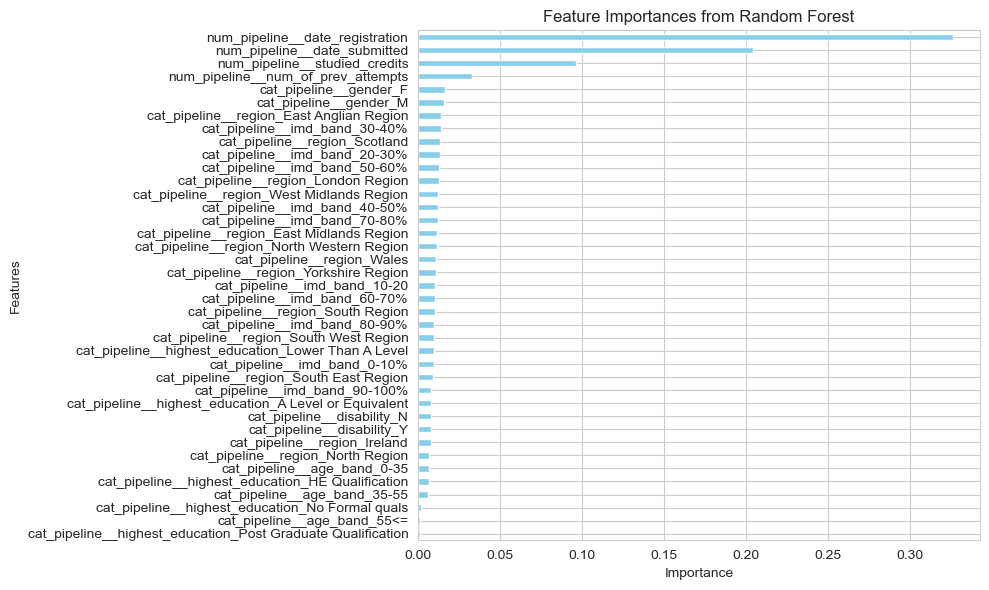

In [369]:
plt.figure(figsize=(10, 6))
sorted_importances.plot(kind='barh', color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importances from Random Forest')
plt.gca().invert_yaxis()  # To have the most important feature at the top
plt.tight_layout()
plt.show()